In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch

#setting device

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple GPU
    print("Using Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA GPU


In [2]:
matrix_likelihoods = torch.from_numpy(np.load('log_prob.npy')).to(device).T

In [14]:
print(matrix_likelihoods[:,1
    ])

tensor([767.0040, 767.0040, 767.0040, 767.0040, 767.0040, 767.0040, 767.0040,
        767.0040, 767.0040, 767.0040, 767.0040, 767.0040, 767.0047, 767.0040,
        767.0040, 767.0040, 767.0040, 767.0040, 767.0040, 767.0040],
       device='cuda:0')


In [4]:
# =========================
# Funzione obiettivo
# =========================
def objective(y, r):
    """
    y: torch.Tensor shape (n,) (parametri liberi)
    r: torch.Tensor shape (n, m) (log-likelihood)
    """
    x = torch.softmax(y, dim=0)  # vettore nel simplex
    log_x = torch.log(x + 1e-16)  # stabilità
    log_terms = torch.logsumexp(log_x[:, None] + r, dim=0)  # log(sum_i x_i * exp(r_ij))
    return -torch.sum(log_terms)

In [5]:
def ottimizza(r, sensibilita=1e-10, pazienza=100, max_iter=50000, verbose=True):
    """
    Esegue l'ottimizzazione con early stopping.
    
    Parametri:
        r: tensore di input
        sensibilita: miglioramento minimo richiesto nella loss per continuare
        pazienza: numero di iterazioni consecutive senza miglioramento dopo cui fermarsi
        max_iter: numero massimo di iterazioni
    """
    r = r.to(device=device)
    n = r.shape[0]
    y = torch.zeros(n, device=device, requires_grad=True)
    
    optimizer = torch.optim.Adam([y], lr=0.05)
    history = []
    
    best_loss = float('inf')
    counter = 0  # conta quante iterazioni senza miglioramento
    
    for it in range(max_iter):
        optimizer.zero_grad()
        loss = objective(y, r)
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        history.append(current_loss)
        
        # Controllo miglioramento
        if best_loss - current_loss > sensibilita:
            best_loss = current_loss
            counter = 0  # reset contatore
        else:
            counter += 1
        
        # Stampa di debug
        if ((it % 50 == 0) and (verbose)):
            print(f"Iter {it:4d} | Loss {current_loss:.6f} | Best {best_loss:.6f} | No improv: {counter}")
        
        # Early stopping
        if counter >= pazienza:
            if verbose:
                print(f"Early stopping a iterazione {it} — nessun miglioramento in {pazienza} step.")
            break
    
    return y, history

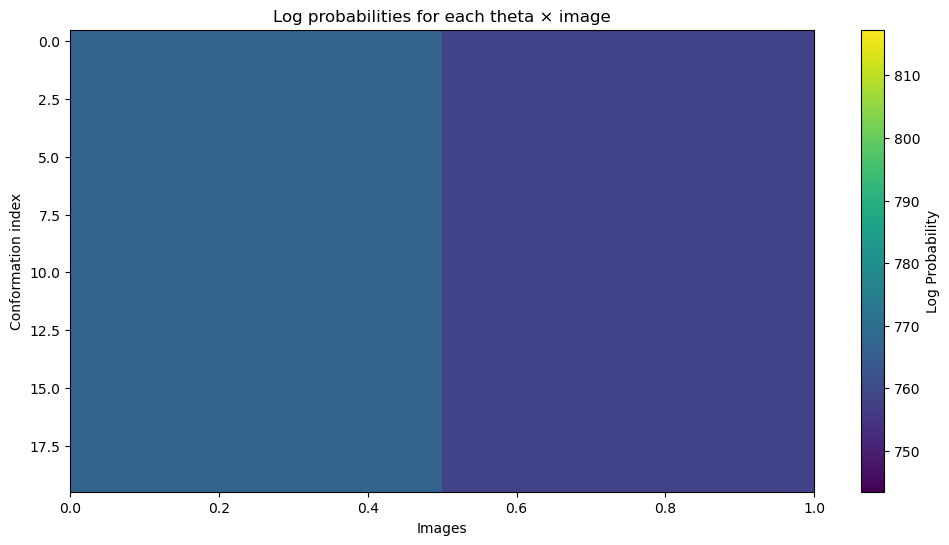

In [9]:
plt.figure(figsize=(12, 6))
plt.imshow(matrix_likelihoods.cpu(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Conformation index')
plt.title('Log probabilities for each theta × image')
plt.xlim(0,1)
plt.show()

In [10]:
ys, _ = ottimizza(matrix_likelihoods,verbose=True)
x_opt = torch.softmax(ys, dim=0).detach().cpu().numpy()
print("Optimal x:", x_opt)
print("Sum of x:", np.sum(x_opt))

Iter    0 | Loss -15318119.000000 | Best -15318119.000000 | No improv: 0
Iter   50 | Loss -15318124.000000 | Best -15318124.000000 | No improv: 16
Iter  100 | Loss -15318126.000000 | Best -15318126.000000 | No improv: 38
Iter  150 | Loss -15318125.000000 | Best -15318126.000000 | No improv: 88
Early stopping a iterazione 162 — nessun miglioramento in 100 step.
Optimal x: [2.6831886e-04 2.6831886e-04 2.6831886e-04 2.6831886e-04 2.6831886e-04
 2.6831886e-04 2.6831886e-04 2.6831886e-04 2.6831886e-04 8.1549864e-03
 2.6831886e-04 2.9260569e-04 9.8693186e-01 2.9084348e-04 2.7829898e-04
 2.6831886e-04 2.6831886e-04 2.6831886e-04 2.6831886e-04 2.9492396e-04]
Sum of x: 1.0000001


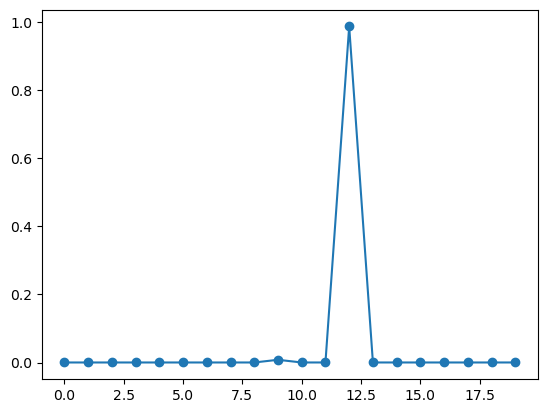

In [11]:
# Plot final weights
plt.plot(x_opt, 'o-')

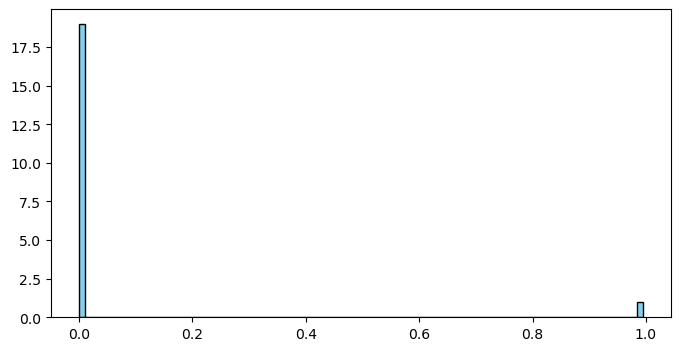

In [12]:
plt.figure(figsize=(8,4))
plt.hist(x_opt, bins=100, color='skyblue', edgecolor='black')
plt.show()

In [13]:
# log_prob_matrix_d is your likelihood matrix [num_theta, num_images]
# Example: log_prob_matrix_d.shape == (100, 5000)

# Pick an image to visualize
image_idx = 0  # first image
log_probs_for_image = log_prob_matrix_d[image_idx:]

# Convert log-prob to probability for nicer visualization
probs_for_image = np.exp(log_probs_for_image - np.max(log_probs_for_image))

# Normalize to sum to 1
probs_for_image /= probs_for_image.sum()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(probs_for_image, marker='o')
plt.xlabel("Theta index")
plt.ylabel("Probability")
plt.title(f"Likelihood distribution over θ for image {image_idx}")
plt.grid(True)
plt.show()

NameError: name 'log_prob_matrix_d' is not defined

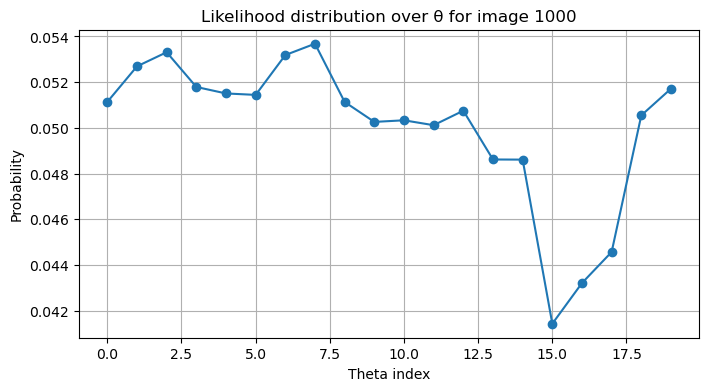

In [18]:
# log_prob_matrix_d is your likelihood matrix [num_theta, num_images]
# Example: log_prob_matrix_d.shape == (100, 5000)

# Pick an image to visualize
image_idx = 1000  # first image
matrix_likelihoods_idx = matrix_likelihoods[:, image_idx].cpu()

# Convert log-prob to probability for nicer visualization
probs_for_image = torch.exp(matrix_likelihoods_idx - torch.max(matrix_likelihoods_idx))

# Normalize to sum to 1
probs_for_image /= probs_for_image.sum()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(probs_for_image, marker='o')
plt.xlabel("Theta index")
plt.ylabel("Probability")
plt.title(f"Likelihood distribution over θ for image {image_idx}")
plt.grid(True)
plt.show()